In [1]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from ibl_info.prepare_data_pid import get_new_cinc_intervals
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl
from tqdm import tqdm
from glob import glob
import re

In [2]:
# one = ONE()
# sessions = one.search(datasets="widefieldU.images.npy")
# print(f"{len(sessions)} sessions with widefield data found")

### Random old tests

In [4]:
hemisphere = ("left", "right")
align_event = "stimOn_times"
min_rt = 0.08
max_rt = None
frame_window = (0, 2)  # this is unnecessary; should be 2 to 0 imo


def check_config():
    """Load config yaml and perform some basic checks"""
    # Get config
    with open(Path(os.getcwd()).parent.joinpath("config.yaml"), "r") as config_yml:
        config = yaml.safe_load(config_yml)
    return config


config = check_config()

# we can pass the proper align times :)
session_id = sessions[0]
sl = SessionLoader(one, eid=session_id)
sl.load_trials()
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)
trials = sl.trials[trials_mask]
_, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(trials, "stim")

  0%|          | 0/50 [00:00<?, ?it/s]

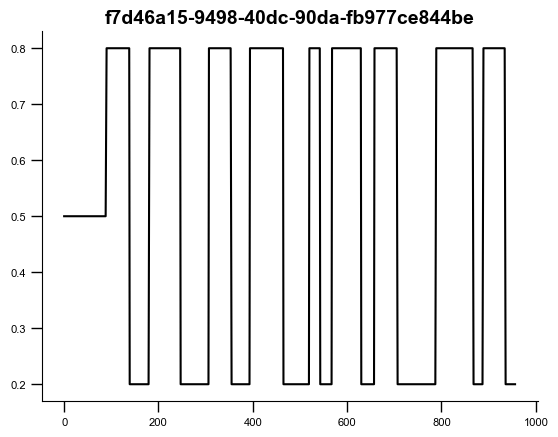

  0%|          | 0/50 [00:00<?, ?it/s]


In [5]:
for session_id in tqdm(sessions):
    sl = SessionLoader(one, eid=session_id)
    sl.load_trials()
    trials_mask = compute_mask(
        sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
    )
    trials = sl.trials[trials_mask]
    plt.plot(trials["probabilityLeft"])
    plt.title(f"{session_id}")
    plt.show()
    break

In [6]:
align_times = trials.stimOn_times.values

In [7]:
significant_regions = [
    ["MOs"],
    ["SSp-ul"],
    ["VISam"],
    ["VISl"],
    ["VISp"],
    ["ACAd"],
    ["PL"],
    ["RSPv"],
    ["VISa"],
]

In [8]:
data_epoch, actual_regions = prepare_widefield(
    one,
    session_id,
    hemisphere,
    regions="single_regions",  # significant_regions,
    align_times=align_times,
    frame_window=frame_window,
    functional_channel=470,
    stage_only=False,
)

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: divide by zero encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: overflow encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: invalid value encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: divide by zero encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: overflow encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: invalid value encountered in matmul
  t = self.Uflat[idx,:]@self.SVT



- so this is data array, and region
- returns in trails x frames x voxels
- transpose them into frames x trials x voxels
- use linear and non-linear decoders
- look at wtf charles is doing to get such nice accuracies

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from ibl_info.decoder_pid import linear_nonlinear_delta

In [ ]:
# do some quick checks, don't include regions with  less than 5 voxels
MIN_UNITS = 5
regions_to_keep = np.zeros(len(actual_regions))
for idx in range(len(actual_regions)):
    if data_epoch[idx].shape[-1] > MIN_UNITS:
        regions_to_keep[idx] = 1
regions_to_keep = np.asarray(regions_to_keep, dtype=np.bool)
data_to_keep = np.where(regions_to_keep == 1)
regions_used = np.asarray(actual_regions)[regions_to_keep]

In [14]:
congruent_target = target_variable[congruent_flags]
incongruent_target = target_variable[incongruent_flags]

In [15]:
import warnings

warnings.filterwarnings("ignore")

In [28]:
region_data = data_epoch[0].transpose(1, 0, 2)  # type: ignore

In [30]:
region_data[0].shape

(767, 155)

In [38]:
def scores_per_region(region_data, target, flags):
    # we can iterate over epochs, maybe over data_to_keep

    LLScores = []
    NLScores = []
    Diffs = []
    # for frame_idx in tqdm(range(3)):
    frame_idx = 1
    frame_data = region_data[frame_idx]
    flagged_targets = target[flags]
    linear_scores, nonlinear_scores, difference = linear_nonlinear_delta(
        flagged_targets, frame_data[flags, :]
    )
    LLScores.append(linear_scores)
    NLScores.append(nonlinear_scores)
    Diffs.append(difference)
    return LLScores, NLScores, Diffs

In [ ]:
# do this for all regions, will take forever anyways
#
congruent_region_scores = {}
incongruent_region_scores = {}
all_region_scores = {}
for region_idx in data_to_keep[0]:  # weird but whatevers
    region_data = data_epoch[region_idx].transpose(1, 0, 2)  # type: ignore
    # do this for only frame 1
    llscores, nlscores, diffs = scores_per_region(
        region_data, target_variable, congruent_flags.values
    )
    congruent_region_scores[regions_used[region_idx][0]] = [llscores, nlscores, diffs]
    llscores, nlscores, diffs = scores_per_region(
        region_data, target_variable, incongruent_flags.values
    )
    incongruent_region_scores[regions_used[region_idx][0]] = [llscores, nlscores, diffs]
    llscores, nlscores, diffs = scores_per_region(
        region_data, target_variable, np.ones(len(target_variable), dtype=bool)
    )
    all_region_scores[regions_used[region_idx][0]] = [llscores, nlscores, diffs]

In [66]:
all_region_scores["MOB"][0]

[array([0.6038961 , 0.57142857, 0.50980392, 0.58823529, 0.58169935])]

In [108]:
scores = np.zeros((len(regions_used), 3, 3))

for idx, key in enumerate(list(all_region_scores.keys())):
    scores[idx, 0, 0] = np.mean(all_region_scores[key][0])
    scores[idx, 0, 1] = np.mean(all_region_scores[key][1])
    scores[idx, 0, 2] = np.mean(all_region_scores[key][2])

    scores[idx, 1, 0] = np.mean(congruent_region_scores[key][0])
    scores[idx, 1, 1] = np.mean(congruent_region_scores[key][1])
    scores[idx, 1, 2] = np.mean(congruent_region_scores[key][2])

    scores[idx, 2, 0] = np.mean(incongruent_region_scores[key][0])
    scores[idx, 2, 1] = np.mean(incongruent_region_scores[key][1])
    scores[idx, 2, 2] = np.mean(incongruent_region_scores[key][2])

In [104]:
regions_used[1]

array(['FRP'], dtype='<U7')

In [110]:
# for idx in range(len(regions_used)):
#     fig, ax = plt.subplots(figsize=(6, 4))
#     bar_width = 0.4
#     ax.bar(
#         np.arange(3),  # - bar_width / 2,
#         scores[idx, :, 2],
#         width=bar_width,
#         edgecolor="k",
#         color=["red", "green", "blue"],
#         alpha=0.5,
#     )
#     # ax.bar(
#     #     np.arange(3) + bar_width / 2,
#     #     scores[idx, :, 1],
#     #     width=bar_width,
#     #     edgecolor="k",
#     #     color=["red", "green", "blue"],
#     #     alpha=0.75,
#     # )
#     ax.set_xticks(np.arange(3), ["all", "congruent", "incongruent"])
#     ax.set_title(f"Region: {regions_used[idx][0]}")

In [111]:
# try to do the single cell thing

In [123]:
from ibl_info.utils import discretize

In [ ]:
frame_we_want = region_data[1]

(3, 767, 243)

In [118]:
# we do equispaced binnings, again 3bins

In [ ]:
frame_we_want.shape

(767, 243)

In [147]:
# now compute mi and do the test?
from statsmodels.stats.multitest import multipletests
import ibl_info.measures.information_measures as info

In [161]:
def mi_per_neuron_permuted(spikes, decoding_variable, n_permutations=100):

    mi_observed = info.corrected_mutual_information(  # type: ignore
        source=spikes, target=decoding_variable, unbiased_measure="plugin"
    )
    # use original permutation statistics
    mi_null = np.zeros(n_permutations)
    for i in range(n_permutations):

        stim_shuffled = np.random.permutation(decoding_variable)
        mi_null[i] = info.corrected_mutual_information(  # type: ignore
            source=spikes, target=stim_shuffled, unbiased_measure="plugin"
        )

    p_value = (np.sum(mi_null >= mi_observed) + 1) / (n_permutations + 1)  # type: ignore
    return mi_observed, p_value

In [162]:
def significant_neurons(spikes, decoding_variable, n_permutations=100, alpha=0.05):

    mi_data = np.zeros((spikes.shape[0]))
    p_values = np.zeros((spikes.shape[0]))
    for idx in tqdm(range(len(mi_data))):
        mi_data[idx], p_values[idx] = mi_per_neuron_permuted(spikes[idx, :], decoding_variable, n_permutations=n_permutations)  # type: ignore

    # do corrections
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=alpha, method="fdr_bh")

    return mi_data, p_values, reject

In [163]:
nneurons = []
for region_idx in data_to_keep[0]:  # weird but whatevers
    region_data = data_epoch[region_idx].transpose(1, 0, 2)  # type: ignore
    frx_n = []
    for frx in range(3):
        frame_we_want = region_data[frx]
        discretized_frame = discretize(frame_we_want.T, n_bins=3)
        mi_data, p_values, reject = significant_neurons(
            discretized_frame, target_variable, n_permutations=100, alpha=0.05
        )
        nx = np.sum(reject)
        frx_n.append(nx)
    nneurons.append(frx_n)

100%|██████████| 243/243 [00:04<00:00, 59.12it/s]


<Axes: >

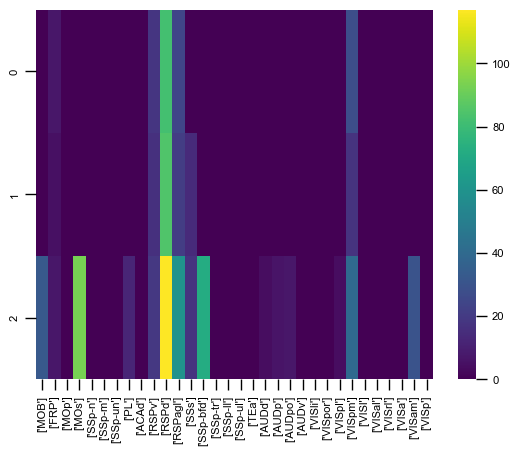

In [ ]:
sns.heatmap(nneurons.T, cmap="viridis", xticklabels=regions_used)

In [ ]:
# frame 0 is useless
# so we look at frame 1 and 2, for all regions. this is gonna take forever: but whatever
# we should store all the data and look at it.

In [ ]:
from itertools import combinations

combinations_regions = []
for x in combinations(range(len(regions_used)), 2):
    combinations_regions.append([x[0], x[1]])

combinations_regions = np.asarray(combinations_regions)

In [35]:
# now what
# for each pair of region
# okay we also first discretize
# so that we minimize io

from ibl_info.utils import discretize


discretized_data_epoch = []

for idx in range(len(regions_to_keep)):

    flag = regions_to_keep[idx]
    if flag == False:
        continue

    # i transpose this into frames x neurons x trials
    region_data = data_epoch[idx].transpose(1, 2, 0)

    discretized_region_data = np.zeros_like(region_data)
    for frame in range(discretized_region_data.shape[0]):
        discretized_region_data[frame, :] = discretize(region_data[frame, :], n_bins=3)

    discretized_data_epoch.append(discretized_region_data)

In [31]:
for region_pairs in combinations_regions:
    print(region_pairs[0], region_pairs[1])
    break

0 1


In [36]:
# now what
# for each idx in combination regions:

region_a = combinations_regions[0][0]
region_b = combinations_regions[0][1]
frame = 3

In [37]:
region_a_data = discretized_data_epoch[region_a][4, :]
region_b_data = discretized_data_epoch[region_b][4, :]

In [38]:
n1 = region_a_data.shape[0]
n2 = region_b_data.shape[0]
region_a_data.shape

(155, 777)

In [39]:
import ibl_info.measures.information_measures as info
from tqdm import tqdm

In [40]:
# there must be a better way to iterate through this

mi_region_a = np.zeros((n1))
mi_region_b = np.zeros((n2))
tvmi_array = np.zeros((n1 * n2))
pid_array = np.zeros((n1 * n2, 4))

idx = 0
for neurona in range(n1):
    mi_neurona = info.corrected_mutual_information(
        target=target_variable, source=region_a_data[neurona, :]
    )
    mi_region_a[neurona] = mi_neurona  # type: ignore
    for neuronb in range(n2):
        mi_neuronb = info.corrected_mutual_information(
            target=target_variable, source=region_a_data[neuronb, :]
        )
        mi_region_b[neuronb] = mi_neuronb  # type: ignore

        tvmi = info.corrected_tvmi(
            source_a=region_a_data[neurona, :],
            source_b=region_b_data[neuronb, :],
            target=target_variable,
        )
        pid = info.corrected_pid(
            sourcea=region_a_data[neurona, :],
            sourceb=region_b_data[neuronb, :],
            target=target_variable,
        )

        tvmi_array[idx] = tvmi  # type: ignore
        pid_array[idx, :] = pid  # type: ignore

        idx = idx + 1

(array([4.66627405e-05, 3.30664161e-04, 2.35455922e-03, 1.28928336e-03]),
 array([0.00241241, 0.00249324, 0.00234998, 0.00430826]))

### Load pid data

In [93]:
from glob import glob
from tqdm import tqdm

In [2]:
files = glob("../data/generated/wfi/*.pkl")

In [6]:
# this is organized a bit differently
# yes
with open(files[0], "rb") as f:
    wifidata = pkl.load(f)

In [8]:
frame_ids = list(wifidata.keys())

In [148]:
region_names = []
for rname in wifidata[0].keys():
    regions = rname.strip("()").replace("'", "").split(", ")
    region_names.append(regions)

In [131]:
def meansem(congruent, incongruent):

    congruent[congruent < 0] = 0
    incongruent[incongruent < 0] = 0

    congruent_mean = np.mean(congruent, axis=0)
    incongruent_mean = np.mean(incongruent, axis=0)

    congruent_sem = np.std(congruent, axis=0) / np.sqrt(congruent.shape[0])
    incongruent_sem = np.std(incongruent, axis=0) / np.sqrt(incongruent.shape[0])

    return np.asarray([congruent_mean, incongruent_mean]), np.asarray(
        [congruent_sem, incongruent_sem]
    )

In [ ]:
conditions = list(wifidata[0][rname].keys())

In [133]:
congruent_pid_frame0 = []
incongruent_pid_frame0 = []

congruent_pid_frame1 = []
incongruent_pid_frame1 = []

congruent_pid_frame2 = []
incongruent_pid_frame2 = []

for filename in tqdm(files):
    # this is organized a bit differently
    # yes

    with open(filename, "rb") as f:
        wifidata = pkl.load(f)

    # frame 0
    frame = 0
    for rname in wifidata[frame].keys():
        congruent_pid_frame0.append(wifidata[frame][rname][conditions[0]]["pid"])
        incongruent_pid_frame0.append(wifidata[frame][rname][conditions[1]]["pid"])

    frame = 1
    for rname in wifidata[frame].keys():
        congruent_pid_frame1.append(wifidata[frame][rname][conditions[0]]["pid"])
        incongruent_pid_frame1.append(wifidata[frame][rname][conditions[1]]["pid"])

    frame = 2
    for rname in wifidata[frame].keys():
        congruent_pid_frame2.append(wifidata[frame][rname][conditions[0]]["pid"])
        incongruent_pid_frame2.append(wifidata[frame][rname][conditions[1]]["pid"])


congruent_pid_frame0 = np.concatenate(congruent_pid_frame0, axis=0)
incongruent_pid_frame0 = np.concatenate(incongruent_pid_frame0, axis=0)

congruent_pid_frame1 = np.concatenate(congruent_pid_frame1, axis=0)
incongruent_pid_frame1 = np.concatenate(incongruent_pid_frame1, axis=0)

congruent_pid_frame2 = np.concatenate(congruent_pid_frame2, axis=0)
incongruent_pid_frame2 = np.concatenate(incongruent_pid_frame2, axis=0)

100%|██████████| 10/10 [00:00<00:00, 120.25it/s]


In [134]:
means_0, sems_0 = meansem(congruent_pid_frame0, incongruent_pid_frame0)
means_1, sems_1 = meansem(congruent_pid_frame1, incongruent_pid_frame1)
means_2, sems_2 = meansem(congruent_pid_frame2, incongruent_pid_frame2)

In [141]:
means_0, means_1, means_2

(array([[0.00595975, 0.00777995, 0.0067433 , 0.01107951],
        [0.00955252, 0.00992132, 0.01171943, 0.0176355 ]]),
 array([[0.00696302, 0.00715134, 0.00789983, 0.01196484],
        [0.01087562, 0.00998064, 0.01157397, 0.01701409]]),
 array([[0.00793667, 0.00650112, 0.00614114, 0.01083666],
        [0.00952965, 0.00988253, 0.0074561 , 0.01844263]]))

In [136]:
def meansem(congruent, incongruent):

    congruent_mean = np.mean(congruent, axis=0)
    incongruent_mean = np.mean(incongruent, axis=0)

    congruent_sem = np.std(congruent, axis=0) / np.sqrt(congruent.shape[0])
    incongruent_sem = np.std(incongruent, axis=0) / np.sqrt(incongruent.shape[0])

    return np.asarray([congruent_mean, incongruent_mean]), np.asarray(
        [congruent_sem, incongruent_sem]
    )

Text(0.5, 1.0, 'Frame 1')

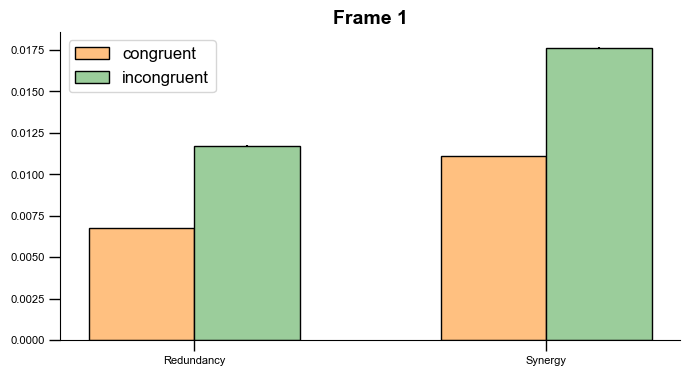

In [145]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent
ax.bar(
    np.arange(2),
    [means_0[0, 2], means_0[0, 3]],
    yerr=[sems_0[0, 2], sems_0[0, 3]],
    width=0.3,
    color=colors[0],
    label="congruent",
    edgecolor="k",
)
ax.bar(
    np.arange(2) + 0.3,
    [means_0[1, 2], means_0[1, 3]],
    yerr=[sems_0[1, 2], sems_0[1, 3]],
    width=0.3,
    color=colors[1],
    label="incongruent",
    edgecolor="k",
)
ax.legend()
ax.set_xticks(np.arange(2) + 0.15, ["Redundancy", "Synergy"])
ax.set_title("Frame 1")

Text(0.5, 1.0, 'Frame 2')

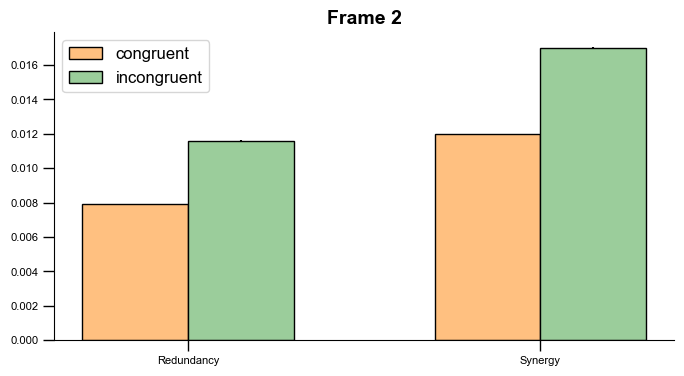

In [143]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent
ax.bar(
    np.arange(2),
    [means_1[0, 2], means_1[0, 3]],
    yerr=[sems_1[0, 2], sems_1[0, 3]],
    width=0.3,
    color=colors[0],
    label="congruent",
    edgecolor="k",
)
ax.bar(
    np.arange(2) + 0.3,
    [means_1[1, 2], means_1[1, 3]],
    yerr=[sems_1[1, 2], sems_1[1, 3]],
    width=0.3,
    color=colors[1],
    label="incongruent",
    edgecolor="k",
)
ax.legend()
ax.set_xticks(np.arange(2) + 0.15, ["Redundancy", "Synergy"])
ax.set_title("Frame 2")

Text(0.5, 1.0, 'Frame 3')

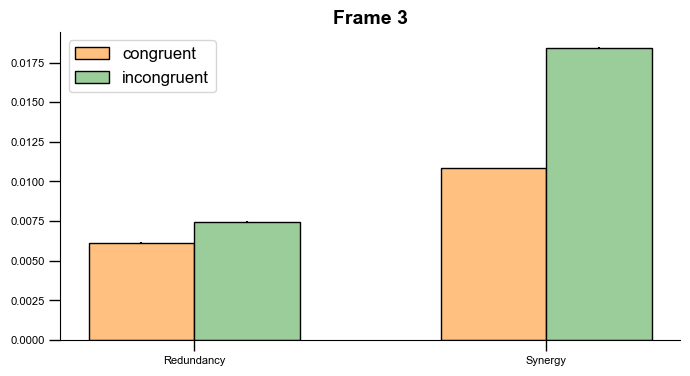

In [142]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent
ax.bar(
    np.arange(2),
    [means_2[0, 2], means_2[0, 3]],
    yerr=[sems_2[0, 2], sems_2[0, 3]],
    width=0.3,
    color=colors[0],
    label="congruent",
    edgecolor="k",
)
ax.bar(
    np.arange(2) + 0.3,
    [means_2[1, 2], means_2[1, 3]],
    yerr=[sems_2[1, 2], sems_2[1, 3]],
    width=0.3,
    color=colors[1],
    label="incongruent",
    edgecolor="k",
)
ax.legend()
ax.set_xticks(np.arange(2) + 0.15, ["Redundancy", "Synergy"])
ax.set_title("Frame 3")

In [150]:
region_names = [item for sublist in region_names for item in sublist]
region_names = np.unique(region_names)

In [151]:
region_names

array(['MOs', 'SSp-ul', 'VISa', 'VISam', 'VISl', 'VISp'], dtype='<U6')

### compute correlation 

In [2]:
def region_redundancy_metrics(region_data, zscore=True):
    # trials x voxels
    X = np.asarray(region_data, dtype=float)

    # Z-score per voxel (so correlations aren’t dominated by scale)
    if zscore:
        X -= X.mean(axis=0, keepdims=True)
        stds = X.std(axis=0, ddof=1)
        stds[stds == 0] = 1.0
        X /= stds

    # --- Voxel–voxel correlation matrix ---
    corr_matrix = np.corrcoef(X, rowvar=False)
    V = corr_matrix.shape[0]
    if V < 2:
        raise ValueError("Need at least 2 voxels in the region to compute correlation.")

    # mean off-diagonal correlation
    mean_corr = (corr_matrix.sum() - V) / (V * (V - 1))

    # --- Participation ratio from covariance ---
    C = np.cov(X, rowvar=False)
    evals = np.linalg.eigvalsh(C)
    evals = np.clip(evals, 0, None)  # remove tiny negatives from numerics
    total = evals.sum()
    if total == 0:
        pr = 0.0
    else:
        pr = (total**2) / np.sum(evals**2)

    return float(mean_corr), float(pr)

In [16]:
len(data_epoch)

32

In [18]:
data_epoch[0].shape

(767, 3, 155)

In [71]:
def summary_stats(data_epoch, mask=None):
    correlation_array = np.zeros((len(data_epoch), 3))
    participation_array = np.zeros((len(data_epoch), 3))
    if mask is None:
        mask = np.ones((data_epoch[0].shape[0]), dtype=np.bool)

    for regions in range(len(data_epoch)):
        for i in range(3):
            corr, pr = region_redundancy_metrics(data_epoch[regions][mask, i, :])
            correlation_array[regions, i] = corr
            participation_array[regions, i] = pr

    return correlation_array, participation_array

In [72]:
def plot_summary(
    correlation_array, participation_array, actual_regions, significant_regions, title
):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        np.arange(32),
        np.mean(correlation_array, axis=1),
        edgecolor="k",
        color="#9bcd9b",
        yerr=np.std(correlation_array, axis=1) / np.sqrt(3),
    )
    ax.set_xticks(np.arange(32), np.concatenate(actual_regions), rotation=90)
    ax.set_title("Correlation")

    for label in ax.get_xticklabels():
        if label.get_text() in np.concatenate(significant_regions):  # condition
            label.set_color("red")
    ax.set_title(title)

In [73]:
_, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(trials, "stim")

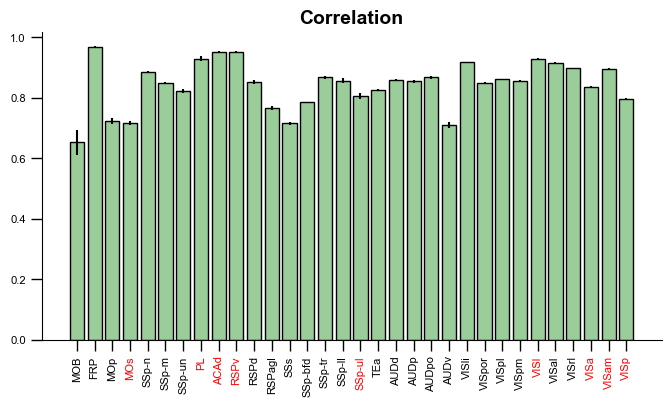

In [74]:
crc_all, _ = summary_stats(data_epoch)

plot_summary(crc_all, None, actual_regions, significant_regions, "Correlation")

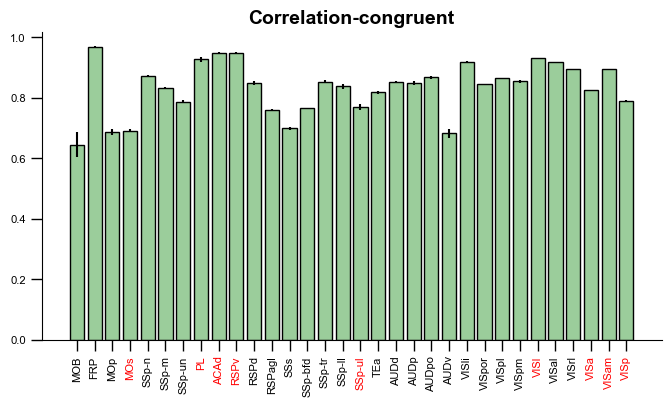

In [75]:
# load up congruent and incongruent
crc_congruent, _ = summary_stats(data_epoch, mask=congruent_flags)

plot_summary(crc_congruent, None, actual_regions, significant_regions, "Correlation-congruent")

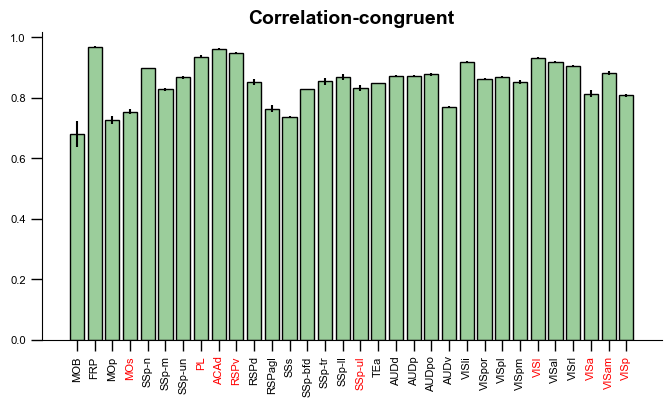

### Correlation statistics

In [4]:
wficorrelationfiles = glob("../data/generated/wfi/correlations/*.pkl")

In [21]:
regions = np.concatenate(
    [
        ["ACAd"],
        ["AUDd"],
        ["AUDp"],
        ["AUDpo"],
        ["AUDv"],
        ["FRP"],
        ["MOB"],
        ["MOp"],
        ["MOs"],
        ["PL"],
        ["RSPagl"],
        ["RSPd"],
        ["RSPv"],
        ["SSp-bfd"],
        ["SSp-ll"],
        ["SSp-m"],
        ["SSp-n"],
        ["SSp-tr"],
        ["SSp-ul"],
        ["SSp-un"],
        ["SSs"],
        ["TEa"],
        ["VISa"],
        ["VISal"],
        ["VISam"],
        ["VISl"],
        ["VISli"],
        ["VISp"],
        ["VISpl"],
        ["VISpm"],
        ["VISpor"],
        ["VISrl"],
    ]
)
string_to_index = {s: i for i, s in enumerate(regions)}

In [34]:
storage = np.zeros((49, 32, 3), dtype=np.float32)
for idx, file in enumerate(wficorrelationfiles):
    with open(file, "rb") as f:
        wifidata = pkl.load(f)
    region_names = np.concatenate(wifidata[3])
    for idy in range(len(region_names)):
        region = region_names[idy]
        for idz in range(3):
            storage[idx, string_to_index[region], idz] = wifidata[0][idy, idz]  # all trials

In [45]:
storage_means = np.nanmean(storage, axis=0)
storage_stds = np.nanmean(storage, axis=0)

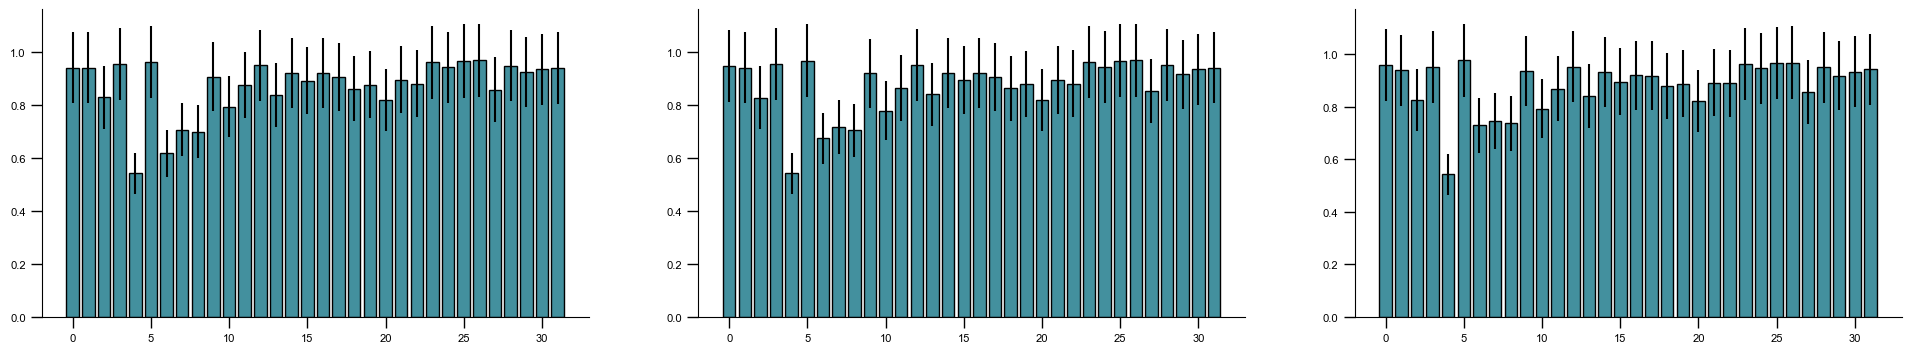

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(24, 4))

for idx in range(3):
    ax[idx].bar(
        np.arange(32),
        storage_means[:, idx],
        edgecolor="k",
        color="#43909e",
        yerr=storage_stds[:, idx] / np.sqrt(49),
    )

[Text(0, 0.5, '$t_0$'), Text(0, 1.5, '$t_1$'), Text(0, 2.5, '$t_2$')]

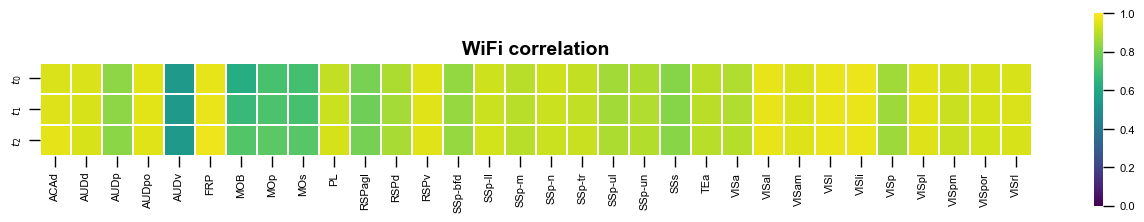

In [73]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    storage_means.T,
    cmap="viridis",
    linecolor="white",
    linewidths=0.25,
    square=True,
    cbar_kws={"shrink": 0.5},
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_xticklabels(regions, rotation=90)
ax.set_title("WiFi correlation")
ax.set_yticklabels(["$t_0$", "$t_1$", "$t_2$"])

### New WiFI

In [ ]:
%load_ext autoreload
%autoreload 2

In [4]:
# look at results
# stim and choice
# different intervals

In [93]:
files = glob("../data/generated/wfi_decoders/choice/equispaced3_pairs/*.pkl")

In [95]:
mean_accuracies = np.zeros((len(files), len(regions), 3, 2))

for file_idx in range(len(files)):

    with open(files[file_idx], "rb") as f:
        d = pkl.load(f)
    frames = list(d.keys())
    pairs = list(d[frames[0]].keys())
    regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
    for f_idx, frame in enumerate(frames):
        for k_idx, k in enumerate(d[frame].keys()):
            results = d[frame][k]["results"]
            mean_a = []
            mean_b = []
            for idx in range(len(results)):
                mean_a.append(results[idx]["balanced_acc_A"])
                mean_b.append(results[idx]["balanced_acc_B"])
            mean_accuracies[file_idx, k_idx, f_idx, 0] = np.mean(mean_a)
            mean_accuracies[file_idx, k_idx, f_idx, 1] = np.mean(mean_b)
            if np.mean(mean_a) == 0:
                print(f"{frame}, {k}, {file}")

In [96]:
means = np.mean(mean_accuracies, axis=0)

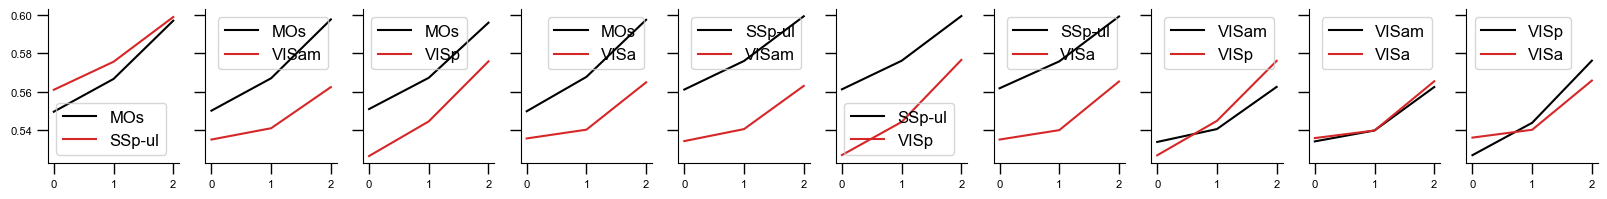

In [97]:
fig, ax = plt.subplots(ncols=len(means), figsize=(20, 2), sharey=True)

for idx in range(len(means)):
    ax[idx].plot(np.arange(3), means[idx, :, 0], label=regions[idx][0])
    ax[idx].plot(np.arange(3), means[idx, :, 1], label=regions[idx][1])
    ax[idx].legend()